In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

class MultipleLinearRegression:

    # Constructor
    def __init__(self):
        self.coefficients = None


    # Train the model
    def fit(self, X, y):

        # Convert into numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        # Add intercept column
        ones = np.ones((X.shape[0], 1))

        # Combine ones with X
        X = np.concatenate((ones, X), axis=1)

        # Normal Equation
        self.coefficients = (
            np.linalg.inv(X.T @ X) @ X.T @ y
        )

        return self.coefficients


    # Prediction
    def predict(self, X):

        X = np.array(X)

        # Add intercept column
        ones = np.ones((X.shape[0], 1))

        X = np.concatenate((ones, X), axis=1)

        # Prediction
        y_pred = X @ self.coefficients

        return y_pred


    # Evaluation
    def evaluate(self, y_actual, y_pred):

        y_actual = np.array(y_actual).reshape(-1, 1)

        # Mean Squared Error
        mse = np.mean((y_actual - y_pred) ** 2)

        # Root Mean Squared Error
        rmse = np.sqrt(mse)

        # R² Score
        ss_total = np.sum(
            (y_actual - np.mean(y_actual)) ** 2
        )

        ss_residual = np.sum(
            (y_actual - y_pred) ** 2
        )

        r2 = 1 - (ss_residual / ss_total)

        print("MSE:", mse)
        print("RMSE:", rmse)
        print("R² Score:", r2)


    # Actual vs Predicted graph
    def plot(self, y_actual, y_pred):

        plt.scatter(y_actual, y_pred)

        plt.xlabel("Actual Sales")
        plt.ylabel("Predicted Sales")

        plt.title("Actual vs Predicted Sales")

        plt.show()

Coefficients:
[[2.92109991]
 [0.04575482]
 [0.18799423]]
MSE: 2.784569900338091
RMSE: 1.6687030593661927
R² Score: 0.8971942610828957


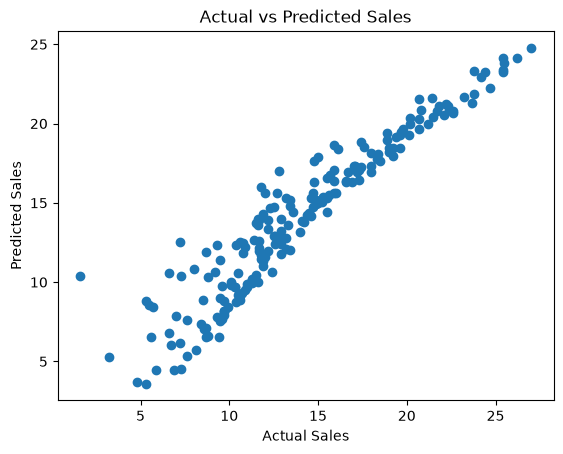

In [ ]:
# Load data
data_path = "https://www.statlearning.com/s/Advertising.csv"

df = pd.read_csv(data_path, index_col=0)


# Select features
X = df[["TV", "radio"]]

# Select target
y = df["sales"]


# Create object
model = MultipleLinearRegression()


# Train
model.fit(X, y)


# Show coefficients
print("Coefficients:")
print(model.coefficients)


# Predict
y_pred = model.predict(X)


# Evaluate
model.evaluate(y, y_pred)


# Visualize
model.plot(y, y_pred)

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=df["TV"],
        y=df["radio"],
        z=df["sales"],
        mode="markers"
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="TV",
        yaxis_title="Radio",
        zaxis_title="Sales"
    ),
    title="3D Plot: TV, Radio and Sales"
)

fig.show()